# Hands, 784 numbers, and a model that cannot fingerspell J

This is **not** digit MNIST. The CSVs in `archive/` are **Sign Language MNIST**: 28×28 photos of hands doing letters.

An ANN does not “see” a hand. It sees **784 grayscale numbers in a line**. Spatial structure is a rumor we will ignore until the CNN lecture.

## What you will actually be able to do

- Load a CSV that *claims* to be images
- Survive the label hole where **J** used to live
- Write the same `Dataset` → `DataLoader` → `nn.Sequential` pipeline as Fashion-MNIST
- Train with SGD and judge whether the model learned letters or vibes

## Honest disclaimer

Subset, not the full 27k. About 20 epochs, not 100. If A and E look the same at 28×28, that is a you-and-the-pixels problem, not a moral failing.


## Setup

Same toys as the Fashion notebook. Seed so the subset is not a lottery. CUDA if you have it, CPU if you are mortal.


In [ ]:
# Shuffle and pick random rows the same way every time we rerun.
import random

# Fast number arrays: images, labels, math.
import numpy as np
# Read the CSV files into tables (rows = hands).
import pandas as pd
# Draw the hand pictures so we can look at them.
import matplotlib.pyplot as plt

# Main PyTorch library: tensors and GPU/CPU.
import torch
# Neural-net building blocks: Linear, ReLU, loss.
import torch.nn as nn
# Optimizers such as SGD that update the weights.
import torch.optim as optim
# Dataset = one sample; DataLoader = a batch of samples.
from torch.utils.data import Dataset, DataLoader
# Cut the table into train and test the same way as the Fashion notebook.
from sklearn.model_selection import train_test_split
# A fixed number so "random" picks are repeatable in class.
SEED = 42
# Lock Python's random module to that seed.
random.seed(SEED)
# Lock NumPy's random picks to the same seed.
np.random.seed(SEED)
# Lock PyTorch's random weight init and shuffles to the same seed.
torch.manual_seed(SEED)

# Use a GPU if one exists; otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# True only on CUDA; we use this later for pin_memory.
use_cuda = device.type == "cuda"
# Show students which device they actually got.
print("device:", device)
# Show whether pin_memory will be on (only useful with a GPU).
print("pin_memory:", use_cuda, "  (a GPU speedhack. on CPU it is a polite lie.)")


device: cpu
pin_memory: False   (a GPU speedhack. on CPU it is a polite lie.)


# 1. Load the CSVs

Kaggle (or whoever zipped this) stored each hand as one row: `label` plus `pixel1` … `pixel784`. That is 28×28 flattened because someone hated folders.

Paths are relative to this notebook. If you launched Jupyter from a random home directory, the next cell will scream. Open the project folder first.


In [ ]:
# Load the training table from disk (each row is one hand).
train_df = pd.read_csv("sign_mnist_train.csv")
# Load the test table the same way (hands the model should not train on).
test_df = pd.read_csv("sign_mnist_test.csv")

# Print how big train is: (number of hands, 1 label + 784 pixels).
print("train:", train_df.shape, "  (rows, label+784 pixels)")
# Print how big test is so we know we have a holdout set.
print("test: ", test_df.shape)
# Show the first few rows so we can see column names and numbers.
train_df.head()


train: (27455, 785)   (rows, label+784 pixels)
test:  (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# List every label in train, sorted, so the missing 9 (J) is obvious.
print("raw train labels:", sorted(train_df["label"].unique()))
# Same check on test, to confirm the hole is in both splits.
print("raw test labels: ", sorted(test_df["label"].unique()))
# Count how many different labels we have (should be 24, not 26).
print("count unique:    ", train_df["label"].nunique())
# Blank line so the next sentences are easier to read.
print()
# Tell the class what the missing 9 means.
print("See that hole at 9? That was J. Z (25) never even showed up.")
# One-line reason J and Z are missing (they need motion, not a still photo).
print("J and Z need motion in ASL. A still photo cannot shrug that hard.")


raw train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
raw test labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
count unique:     24

See that hole at 9? That was J. Z (25) never even showed up.
J and Z need motion in ASL. A still photo cannot shrug that hard.


# 2. Look at the hands

Reshape 784 → 28×28 and plot grayscale. Titles are letters, not integers, because “label 17” is how you lose a classroom.

`cmap="gray"` is not optional unless you enjoy a random colormap pretending a palm is a heatmap.


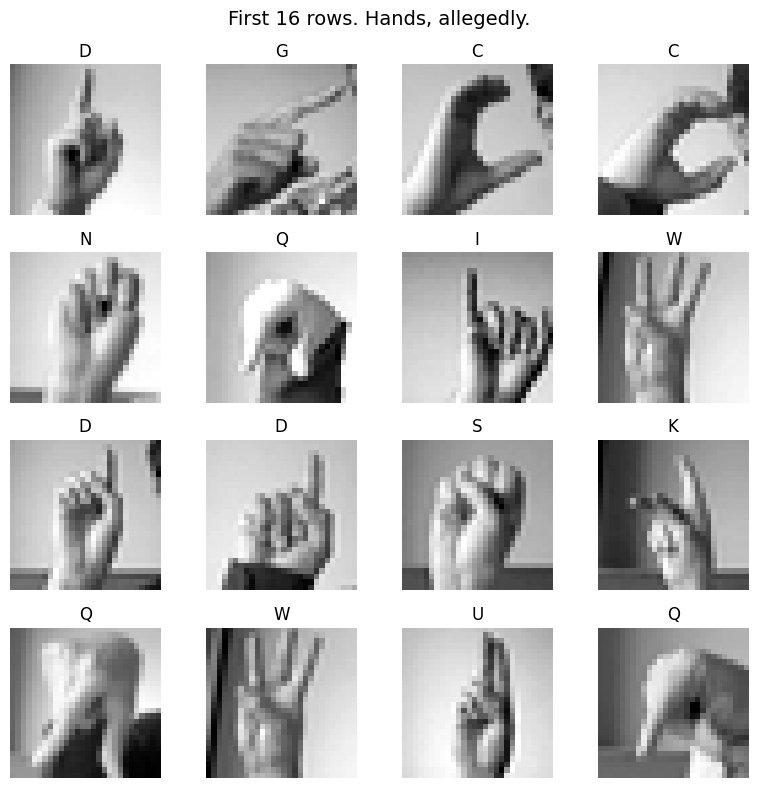

In [ ]:
# Turn a raw number label into a letter (0→A, 1→B, ... 10→K).
def raw_to_letter(y):
    # Start at "A" (code 65) and walk y steps forward in the alphabet.
    return chr(ord("A") + int(y))


# Make a 4-by-4 grid of empty picture slots.
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
# Put one title above the whole grid.
fig.suptitle("First 16 rows. Hands, allegedly.", fontsize=14)

# Fill each of the 16 slots with one training image.
for i, ax in enumerate(axes.flat):
    # Grab row i (label in column 0, pixels in the rest).
    row = train_df.iloc[i]
    # Skip the label, take 784 pixels, make them a 28×28 picture.
    img = row.iloc[1:].values.astype(np.float32).reshape(28, 28)
    # Draw it in grayscale (not a random color map).
    ax.imshow(img, cmap="gray")
    # Title is the letter, so students do not have to decode "17".
    ax.set_title(raw_to_letter(row["label"]))
    # Hide x/y ticks; they add noise, not information.
    ax.axis("off")

# Stop titles and pictures from overlapping.
plt.tight_layout()
# Actually display the figure in the notebook.
plt.show()


# 3. The J-shaped pothole

`CrossEntropyLoss` wants class ids **0, 1, 2, …, C-1** with no skipped numbers. Ours skip 9.

Fix: if the label is bigger than 9, subtract 1. Then we have **24 contiguous classes**.

The output layer is 24, not 26, not 10. Fashion-MNIST had 10 kinds of clothing. We have 24 kinds of hand. Do not copy the 10 from muscle memory.


In [ ]:
# Close the hole at 9 so labels become 0,1,2,... with no skips.
def remap_label(y):
    # Make sure we are working with a plain Python integer.
    y = int(y)
    # If it is K or later (raw 10+), shift down by 1 to fill J's empty seat.
    return y - 1 if y > 9 else y


# 26 letters, drop J (index 9) and Z (index 25); that is our 24-class alphabet.
LETTERS = [chr(ord("A") + i) for i in range(26) if i not in (9, 25)]  # A-Y except J
# Map remapped id 0→A, 1→B, ... 9→K so we can print letters later.
idx_to_letter = {i: ch for i, ch in enumerate(LETTERS)}
# Show the 24 letters the network is allowed to predict.
print("24 letters the model is allowed to guess:", "".join(LETTERS))


# Apply remap_label to every row in a table.
def remap_frame(df):
    # Copy so we do not silently change the original by accident.
    out = df.copy()
    # Replace the label column with the contiguous 0–23 ids.
    out["label"] = out["label"].map(remap_label)
    # Hand back the fixed table.
    return out


# Peek at raw labels before the fix (should still show a missing 9).
print("before:", sorted(train_df["label"].unique())[:12], "...")
# Fix train labels in place for the rest of the notebook.
train_df = remap_frame(train_df)
# Fix test labels the same way (train and test must speak the same ids).
test_df = remap_frame(test_df)
# Confirm the hole is gone: 0 through 23.
print("after: ", sorted(train_df["label"].unique()))
# Confirm we still have 24 classes, not 25.
print("num classes:", train_df["label"].nunique())
# Crash now if we do not have exactly 24 classes (better than a silent bug later).
assert train_df["label"].nunique() == 24
# Crash if any id is missing or outside 0–23.
assert set(train_df["label"].unique()) == set(range(24))


24 letters the model is allowed to guess: ABCDEFGHIKLMNOPQRSTUVWXY
before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12)] ...
after:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
num classes: 24


# 4. Subset so class ends this century

Full train is ~27k rows. We keep about **80 per class** for train and **20 per class** for test. Stratified, seeded. The model will still have opinions. They may be wrong.


In [ ]:
# How many hands to keep for each letter before we split (keeps class short).
SAMPLES_PER_CLASS = 100


# Pick n random rows from every letter, same seed every run.
def subset_per_class(df, n, seed=SEED):
    # We will collect one mini-table per letter here.
    parts = []
    # Split the table into groups that share the same label.
    for _, group in df.groupby("label"):
        # Do not ask for more rows than this letter actually has.
        take = min(n, len(group))
        # Random sample of that many rows, repeatable because of seed.
        parts.append(group.sample(n=take, random_state=seed))
    # Glue groups together, shuffle the mix, and reset row numbers to 0,1,2...
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


# Glue official train and test into one table; we will split it ourselves next.
all_df = pd.concat([train_df, test_df], ignore_index=True)
# Keep 100 random hands per letter so we are not training on 27k rows in class.
small_df = subset_per_class(all_df, SAMPLES_PER_CLASS)

# Pixel columns as a numpy array (still 0–255 until the next cell).
X = small_df.iloc[:, 1:].values
# Letter ids as integers (what the split and the loss both want).
y = small_df.iloc[:, 0].values.astype(np.int64)

# 80% train, 20% test. stratify=y keeps every letter in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Print subset size: 100 letters × 24 classes.
print(f"subset: {len(small_df)}  ({SAMPLES_PER_CLASS} x 24 = {SAMPLES_PER_CLASS * 24})")
# Print split sizes: should be about 1920 train and 480 test.
print(f"train: {len(X_train)}   test: {len(X_test)}")
# Quick reminder of why stratify exists.
print("stratify=y so we did not dump all the A's into train by accident.")


subset: 2400  (100 x 24 = 2400)
train: 1920   test: 480
stratify=y so we did not dump all the A's into train by accident.


# 5. Pixels into [0, 1]

Neural nets prefer 0–1 over 0–255. Divide by 255. That is the entire preprocessing pipeline. No resize drama. These already are 28×28.


In [ ]:
# Scale train pixels from 0–255 down to 0–1. float32 is what the net expects.
X_train = X_train.astype(np.float32) / 255.0
# Scale test the same way. Same 255, no extra statistics from test.
X_test = X_test.astype(np.float32) / 255.0

# Check train images: shape plus that values really sit in [0, 1].
print("X_train", X_train.shape, X_train.min(), X_train.max())
# Check train labels: how many, and the min/max id (should be 0 and 23).
print("y_train", y_train.shape, y_train.min(), y_train.max())
# Check test image shape (about 20% of the subset).
print("X_test ", X_test.shape)
# Remind students one row is a flattened 28×28 picture.
print("one row is 784 floats. a picture, legally speaking.")


X_train (1920, 784) 0.0 1.0
y_train (1920,) 0 23
X_test  (480, 784)
one row is 784 floats. a picture, legally speaking.


# 6. Custom Dataset

PyTorch does not read pandas. It reads `__getitem__`.

Same class as Fashion-MNIST: stash features as `float32`, labels as `long`, return `(x, y)` for index `i`. `__getitem__` is “give me sample i.” That is the entire API.


In [ ]:
# A PyTorch Dataset: give it arrays, get back (image, label) by index.
class CustomDataset(Dataset):
    # Run once when we create the dataset; store the data.
    def __init__(self, features, labels):
        # Turn the pixel numpy array into a float tensor.
        self.features = torch.tensor(features, dtype=torch.float32)
        # Turn the labels into a long tensor (required for CrossEntropy).
        self.labels = torch.tensor(labels, dtype=torch.long)

    # How many samples we have; DataLoader uses this to know when to stop.
    def __len__(self):
        return len(self.features)

    # "Give me sample number index": one image and its letter-id.
    def __getitem__(self, index):
        return self.features[index], self.labels[index]


# Wrap the training arrays so PyTorch can index them.
train_dataset = CustomDataset(X_train, y_train)
# Wrap the test arrays the same way (no shuffling later).
test_dataset = CustomDataset(X_test, y_test)

# Pull sample 0 to prove the Dataset actually returns something.
x0, y0 = train_dataset[0]
# Print its shape (should be 784) and the letter name.
print("one sample →", tuple(x0.shape), "  letter", idx_to_letter[int(y0)])
# Print sizes so they match 1920 and 480.
print("len train/test:", len(train_dataset), len(test_dataset))


one sample → (784,)   letter B
len train/test: 1920 480


# 7. DataLoader

Dataset is a vending machine. DataLoader is the cafeteria tray: batch 32, shuffle train, do not shuffle test.

One batch should be **`[32, 784]`**. If you see `[32, 28, 28]`, you wandered into CNN land early.


In [ ]:
# How many hands to feed the model at once.
BATCH_SIZE = 32

# Train loader: 32 at a time, shuffled so we do not always see A's first.
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=use_cuda
)
# Test loader: 32 at a time, no shuffle, so the score is stable.
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=use_cuda
)

# Grab one training batch so we can inspect shapes.
xb, yb = next(iter(train_loader))
# Should be [32, 784] — batch of flattened images.
print("batch X:", tuple(xb.shape), "  → [B, 784]")
# Should be [32] — one label per image.
print("batch y:", tuple(yb.shape), "  → [B]")
# Translate the first 8 ids into letters for a sanity check.
print("letters:", [idx_to_letter[int(i)] for i in yb[:8]], "...")
# How many batches per epoch (1920/32 = 60, 480/32 = 15).
print("train batches:", len(train_loader), "  test batches:", len(test_loader))


batch X: (32, 784)   → [B, 784]
batch y: (32,)   → [B]
letters: ['T', 'S', 'R', 'X', 'I', 'H', 'Y', 'K'] ...
train batches: 60   test batches: 15


# 8. The ANN (a.k.a. a stack of matrix multiplies)

Three linear layers. ReLU in between. No convolutions. The hand is soup.

$$
784 \xrightarrow{\text{Linear}} 128 \xrightarrow{\text{ReLU}} 64 \xrightarrow{\text{ReLU}} 24
$$

24 logits. No softmax in the model. `CrossEntropyLoss` already does that. Stack another softmax and you get a confident dummy with worse math.


In [ ]:
# The network: three Linear layers with ReLU in between.
class MyNN(nn.Module):
    # Save layer sizes and build the stack once.
    def __init__(self, num_features, num_classes):
        # Hook this class into PyTorch's nn.Module (required).
        super().__init__()
        # Layers run in order: 784→128→64→24.
        self.model = nn.Sequential(
            # First hidden layer: 784 pixels become 128 numbers.
            nn.Linear(num_features, 128),
            # Turn negatives to 0 so the net can learn curves, not just lines.
            nn.ReLU(),
            # Second hidden layer: 128 numbers become 64.
            nn.Linear(128, 64),
            # Another ReLU, same reason.
            nn.ReLU(),
            # Output layer: 64 numbers become 24 scores (one per letter).
            nn.Linear(64, num_classes),
        )

    # What happens on a forward pass: send x through the stack.
    def forward(self, x):
        return self.model(x)


# 784: how many pixels per image (the input size).
num_features = X_train.shape[1]
# 24: how many letters we predict (not 10, not 26).
num_classes = 24
# Build the net and move its weights onto GPU or CPU.
model = MyNN(num_features, num_classes).to(device)
# Print the architecture so students can match it to the markdown.
print(model)

# Fake batch of 2 images, same device as the model, to test shapes.
dummy = torch.randn(2, num_features, device=device)
# No gradients: this is just a shape check, not training.
with torch.no_grad():
    # Run the dummy through; we only care that it does not crash.
    logits = model(dummy)
# Confirm input was [2, 784].
print("dummy in: ", tuple(dummy.shape))
# Confirm output was [2, 24] — two images, 24 letter scores each.
print("logits out:", tuple(logits.shape), "  ← 24 scores, not 10, not 26")


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=24, bias=True)
  )
)
dummy in:  (2, 784)
logits out: (2, 24)   ← 24 scores, not 10, not 26


# 9. Train

Sacred order. Tattoo it:

1. `zero_grad` — last step’s gradients are leftovers
2. **forward**
3. **loss**
4. **backward**
5. **step**

The Fashion notebook put `zero_grad` *after* forward. That still works in PyTorch because backward has not run yet, but it teaches the wrong story. Gradients belong to the previous step. Kill them first.

SGD, `lr=0.1`, **20 epochs**. Not 100. Class is not a monastery.


In [ ]:
learning_rate = 0.1
epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_losses = []

for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0.0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch: {epoch + 1} , Loss: {avg_loss:.4f}")

print("\ndone. if you expected fluent ASL, that is a different course.")


Epoch: 1 , Loss: 3.1768
Epoch: 2 , Loss: 3.1321
Epoch: 3 , Loss: 3.0003
Epoch: 4 , Loss: 2.8825
Epoch: 5 , Loss: 2.7035
Epoch: 6 , Loss: 2.5933
Epoch: 7 , Loss: 2.5372
Epoch: 8 , Loss: 2.3141
Epoch: 9 , Loss: 2.2730
Epoch: 10 , Loss: 2.1654
Epoch: 11 , Loss: 2.1040
Epoch: 12 , Loss: 2.2095
Epoch: 13 , Loss: 2.0028
Epoch: 14 , Loss: 1.8812
Epoch: 15 , Loss: 1.8145
Epoch: 16 , Loss: 1.7411
Epoch: 17 , Loss: 1.7765
Epoch: 18 , Loss: 1.8751
Epoch: 19 , Loss: 1.6326
Epoch: 20 , Loss: 1.6583

done. if you expected fluent ASL, that is a different course.


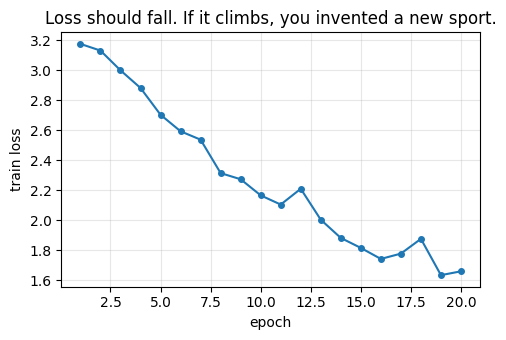

In [ ]:
# Open a small figure for the loss curve.
plt.figure(figsize=(5, 3.5))
# X = epoch number 1..20, Y = that epoch's average train loss.
plt.plot(range(1, epochs + 1), train_losses, marker="o", markersize=4)
# Label the x-axis.
plt.xlabel("epoch")
# Label the y-axis.
plt.ylabel("train loss")
# Title: we want this line to go down over time.
plt.title("Loss should fall. If it climbs, you invented a new sport.")
# Light grid so students can read values off the plot.
plt.grid(True, alpha=0.3)
# Fit labels inside the figure.
plt.tight_layout()
# Show the plot in the notebook.
plt.show()


# 10. Evaluation

`model.eval()` plus `no_grad()`. Argmax of logits is the guess.

We score **test** (the honest one) and **train** (the “did we memorize?” one). If train is 99% and test is coin-flip, the model crammed the homework and failed the exam.

Then a few pictures. If it calls S an R, look at the image. You might also call it an R.


In [ ]:
# Count correct guesses over a loader; return fraction correct.
def accuracy(loader):
    # Eval mode: layers like dropout (we don't have them) would behave correctly.
    model.eval()
    # How many we got right so far.
    correct = 0
    # How many images we have scored so far.
    total = 0
    # Do not build a training graph; we are only measuring.
    with torch.no_grad():
        # Walk every batch in this loader.
        for batch_features, batch_labels in loader:
            # Images on the model's device.
            batch_features = batch_features.to(device)
            # Labels on the same device so we can compare.
            batch_labels = batch_labels.to(device)
            # Pick the letter with the biggest score for each image.
            predicted = model(batch_features).argmax(dim=1)
            # Add this batch's size to the total.
            total += batch_labels.shape[0]
            # Add how many predictions matched the true labels.
            correct += (predicted == batch_labels).sum().item()
    # Fraction correct (0.425 means 42.5%).
    return correct / total


# Honest score: hands the model did not train on.
test_acc = accuracy(test_loader)
# Homework score: if this is huge and test is tiny, we memorized.
train_acc = accuracy(train_loader)
# What you get if you guess a random letter out of 24.
chance = 1.0 / num_classes
# Print test accuracy as a decimal and a percent.
print(f"test accuracy:  {test_acc:.3f}   ({100 * test_acc:.1f}%)")
# Print train accuracy the same way.
print(f"train accuracy: {train_acc:.3f}   ({100 * train_acc:.1f}%)")
# Print chance so students have a floor to beat.
print(f"random guessing: {chance:.3f}   ({100 * chance:.1f}%)")


test accuracy:  0.529   (52.9%)
train accuracy: 0.577   (57.7%)
random guessing: 0.042   (4.2%)


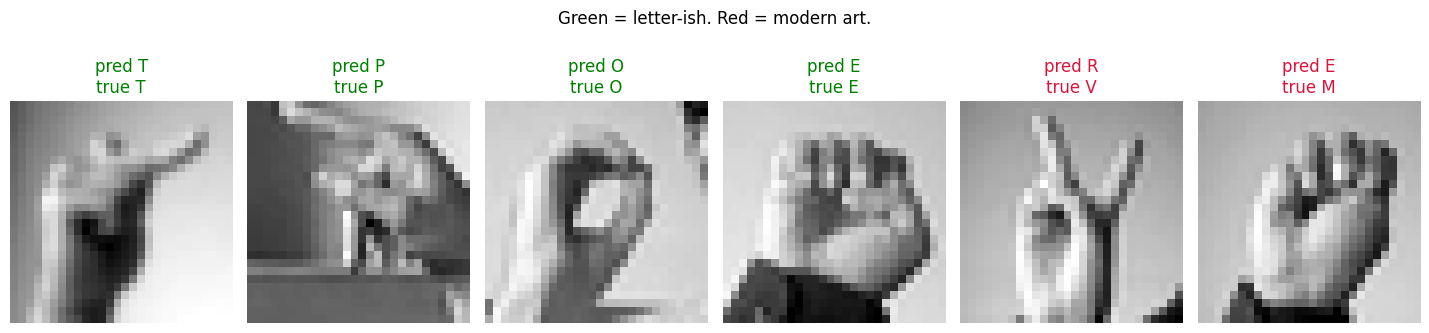

In [ ]:
# How many test pictures to draw.
N_SHOW = 6
# Take the first test batch (images and labels).
vis_x, vis_y = next(iter(test_loader))
# Keep only the first 6 images.
vis_x = vis_x[:N_SHOW]
# Keep only the first 6 true labels, matching those images.
vis_y = vis_y[:N_SHOW]

# Eval mode again; we are guessing, not training.
model.eval()
# No gradient: display only.
with torch.no_grad():
    # Predict on GPU/CPU, then bring the ids back to CPU for matplotlib.
    preds = model(vis_x.to(device)).argmax(dim=1).cpu()

# One row of N_SHOW subplots.
fig, axes = plt.subplots(1, N_SHOW, figsize=(2.4 * N_SHOW, 3.2))
# Pair each axis with its image, true id, and predicted id.
for ax, flat, true_y, pred_y in zip(axes, vis_x, vis_y, preds):
    # 784 numbers back into a 28×28 grayscale hand.
    ax.imshow(flat.reshape(28, 28), cmap="gray")
    # True letter for the title.
    true_ch = idx_to_letter[int(true_y)]
    # Predicted letter for the title.
    pred_ch = idx_to_letter[int(pred_y)]
    # True if the guess matched.
    ok = pred_y == true_y
    # Green title if right, red if wrong.
    ax.set_title(f"pred {pred_ch}\ntrue {true_ch}", color=("green" if ok else "crimson"))
    # Hide axes ticks.
    ax.axis("off")

# Caption above the row of pictures.
plt.suptitle("Green = letter-ish. Red = modern art.", y=1.08)
# Keep titles from clipping.
plt.tight_layout()
# Show the grid.
plt.show()


## Recap

You classified **hands**, not flowers, not digits, with a **fully connected** net:

1. CSV of 784 pixels
2. Remap the missing J so CrossEntropy does not eat a hole
3. Subset, divide by 255
4. `CustomDataset` / `DataLoader`
5. `784 → 128 → 64 → 24`
6. SGD, 20 epochs, zero_grad first
7. Test accuracy, train accuracy, a few guesses

An ANN treats a hand like a bag of numbers. A CNN would respect that fingers have neighbors. That is the next lecture, if this one did not already ruin your evening.

Run all cells top to bottom from the project folder. If paths explode, you are in the wrong working directory.
